# Male Deepfake Speech  Audio Detection Model

## The explanations for this notebook are in the full report. This notebook is more focused on generating the figures and results.

This notebook walks through the analysis of deepfake audio detection models that are trained only using male audio samples.

## Motivation
I wanted to investigate the effectiveness of machine/deep learning models on sparse data.

## Research Subquestion(s)
- Do machine/deep learning models that are trained only on male audio generalize to female audio? If so, why?
- What are some of the most important features in differentiating real and fake male audio samples?

## Models Used
- Simple Neural Network
- Complex Neural Network
- Extreme Gradient Boosting

In [ ]:
# Import necessary packages
import librosa
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import pandas as pd
import numpy as np
import os
import seaborn as sns
import shap

# define torch device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data Pre-processing

- Relevant audio features and labels have been extracted from the data via audio_processing.py. For the sake of simplicity, the dataset generated from that script will be loaded here.

In [ ]:
# Load the male audio data
combined_male_df = pd.read_csv("/content/drive/My Drive/LING_199/combined_male_df.csv")

# rename 'label' to 'LABEL' if necessary
if 'label' in combined_male_df.columns and 'LABEL' not in combined_male_df.columns:
    combined_male_df = combined_male_df.rename(columns={'label': 'LABEL'})

# rename 'FAKE' as 1 and 'REAL' as 0 if necessary
if 'FAKE' in combined_male_df['LABEL'].unique() and 'REAL' in combined_male_df['LABEL'].unique():
    combined_male_df['LABEL'] = combined_male_df['LABEL'].map({'FAKE': 1, 'REAL': 0})

# randomly undersample the fake class to be the same as the real class
fake_samples = combined_male_df[combined_male_df['LABEL'] == 1]
real_samples = combined_male_df[combined_male_df['LABEL'] == 0]
fake_samples_undersampled = fake_samples.sample(n=len(real_samples), random_state=42)
combined_male_df = pd.concat([real_samples, fake_samples_undersampled])

# Separate features and labels
X_male = combined_male_df.drop(columns=['LABEL']).values
y_male = combined_male_df['LABEL'].values

# Split into training and testing sets
X_train_male, X_test_male, y_train_male, y_test_male = train_test_split(
    X_male, y_male, test_size=0.2, stratify=y_male, random_state=42
)

# load the full female data
combined_female_df = pd.read_csv("/content/drive/My Drive/LING_199/combined_female_df.csv")

# balance the data based on label
fake_samples = combined_female_df[combined_female_df['label'] == 1]
real_samples = combined_female_df[combined_female_df['label'] == 0]
fake_samples_undersampled = fake_samples.sample(n=len(real_samples), random_state=42)
combined_female_df = pd.concat([real_samples, fake_samples_undersampled])

## Simple Neural Network

First, I fit a simple neural network to the male data and gauged its effectiveness on a male test set, as well as a female test set.

- The simple Neural Network consists of three linear layers with ReLU activation functions, taking in input features and producing binary classification outputs. Key training hyperparameters include a learning rate of 0.001, batch size of 32, and training over 10 epochs. To evaluate model performance robustly, 10-fold cross-validation is employed, where the data is split into 10 parts, rotating through training and validation roles to reduce overfitting and better estimate generalization. After training, the final model is evaluated on a held-out test set to report overall accuracy.

- To interpret the model’s decision-making process, SHAP (SHapley Additive exPlanations) is used to compute feature importance scores. Using 100 samples each from the training and test datasets, SHAP values are computed to reveal how each input feature contributes to the model's predictions. This is achieved by wrapping the PyTorch model into a callable function compatible with SHAP’s explainer. The resulting summary plots help identify which features consistently influence predictions across examples, enhancing model transparency and interpretability—crucial for assessing fairness and trustworthiness in applications like deepfake detection.

In [ ]:
# Simple Neural Network Class
class SimpleNN(nn.Module):
    def __init__(self, input_size, num_classes):
        super(SimpleNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(inplace=False),
            nn.Linear(128, 64),
            nn.ReLU(inplace=False),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
# Load a previously trained male model
male_model = torch.load('/content/drive/My Drive/LING_199/trained_models/male_models/96.44_basic_male_model_balanced.pth', weights_only=False)

In [ ]:
'''
Classification report on Basic NN male model on its own test set
'''
# Collect all test data in a single tensor
X_test_tensor_male = torch.tensor(X_test_male, dtype=torch.float32).to(device)
with torch.no_grad():
    logits = male_model(X_test_tensor_male)
    probabilities = torch.softmax(logits, dim=1).cpu().numpy()

# Convert probabilities to predicted labels
predicted_labels = np.argmax(probabilities, axis=1)
print("\nClassification Report:")
print(classification_report(y_test_male, predicted_labels, target_names=["REAL", "FAKE"]))


Classification Report:
              precision    recall  f1-score   support

        REAL       1.00      0.93      0.96       253
        FAKE       0.93      1.00      0.97       253

    accuracy                           0.96       506
   macro avg       0.97      0.96      0.96       506
weighted avg       0.97      0.96      0.96       506



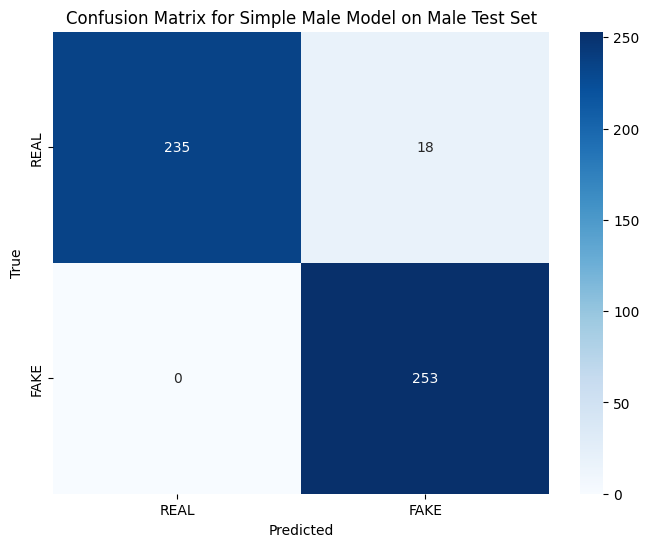

In [ ]:
# Confusion matrix for male test set
cm = confusion_matrix(y_test_male, predicted_labels)

## format the confusion matrix and plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['REAL', 'FAKE'], yticklabels=['REAL', 'FAKE'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Simple Male Model on Male Test Set')
plt.show()

Trained Basic Male Model on Female Dataset Accuracy: 0.8454


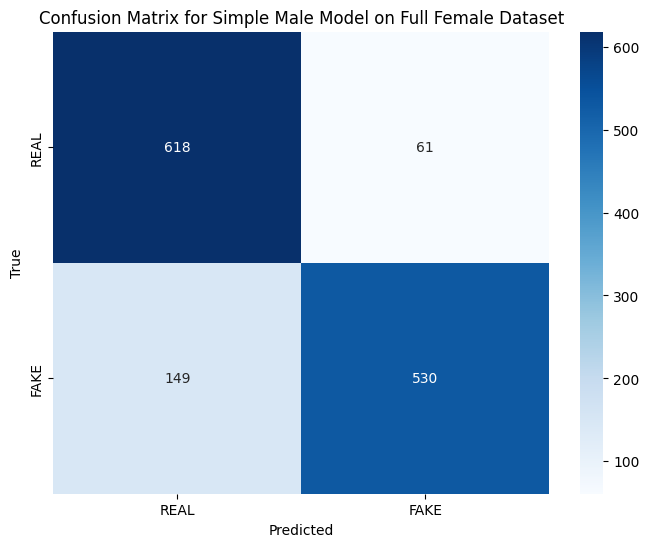

In [ ]:
# Confusion matrix for female dataset

# Ensure correct column order and drop label if present
feature_names = combined_female_df.columns.drop('label').tolist()
X_new = combined_female_df[feature_names].values  # use same feature_names list from training

# define the device, cuda if available, cpu otherwise
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Convert to tensor and send to device
X_new_tensor = torch.tensor(X_new, dtype=torch.float32).to(device)

# set the model to evaluation mode
male_model.eval()
with torch.no_grad():
    outputs = male_model(X_new_tensor)
    _, predictions = torch.max(outputs, 1)  # For classification

y_new = combined_female_df['label'].values
y_new_tensor = torch.tensor(y_new, dtype=torch.long).to(device)

correct = (predictions == y_new_tensor).sum().item()
accuracy = correct / len(y_new)
print(f"Trained Basic Male Model on Female Dataset Accuracy: {accuracy:.4f}")

# Make a confusion matrix
cm = confusion_matrix(y_new, predictions.cpu().numpy())

## format the confusion matrix and plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['REAL', 'FAKE'], yticklabels=['REAL', 'FAKE'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Simple Male Model on Full Female Dataset')
plt.show()

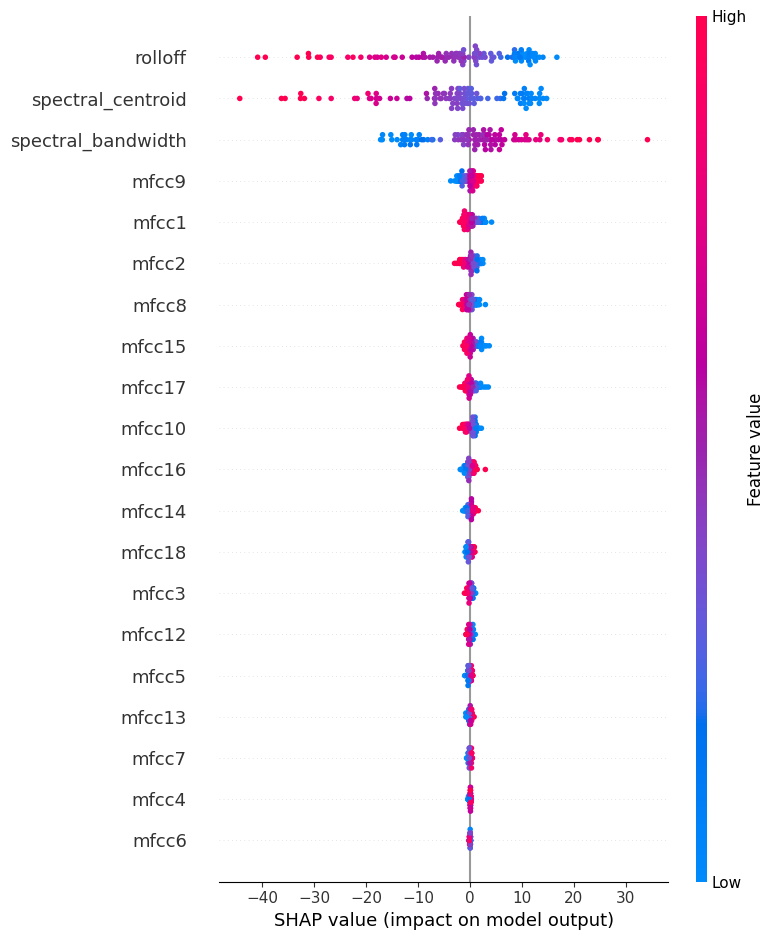

In [ ]:
'''Simple Male Neural Network Shap Plot
'''

# Convert model to evaluation mode
male_model.eval()

# prepare data for shap
background = torch.tensor(X_train_male[:100], dtype=torch.float32).to(device)

# subset the first 100 test samples for feature explanation
X_test_tensor = torch.tensor(X_test_male[:100], dtype=torch.float32).to(device)

# Create a SHAP GradientExplainer, for PyTorch neural networks
explainer = shap.GradientExplainer(male_model, background)

# Get SHAP values for a subset of the test set
shap_values = explainer.shap_values(X_test_tensor_male[:100])

# transform shap values for plotting
shap_values = shap_values[:, :, 1]  # Now shape is (100, 26)

# extract feature names from original dataframe
feature_names = combined_male_df.drop(columns=['LABEL']).columns.tolist()

# Convert to numpy if needed
if torch.is_tensor(shap_values):
    shap_values = shap_values.cpu().numpy()

# Create SHAP summary plot
shap.summary_plot(shap_values, X_test_male[:100], feature_names=feature_names, rng=42)

# Complex Neural Network

- The Complex Neural Network model introduces a deeper architecture. It consists of five fully connected layers, with progressively decreasing hidden dimensions (256 → 128 → 64 → 32 → 1). Each of the first four layers is followed by batch normalization to stabilize learning, ReLU and Swish activation functions for non-linearity, and dropout with a rate of 0.3 to prevent overfitting. The final layer uses a sigmoid activation to output probabilities. The model is trained using a 10-fold stratified cross-validation loop to ensure robustness across splits, with binary cross-entropy as the loss function and the Adam optimizer (learning rate = 0.001). Training is performed for 10 epochs with a batch size of 32.

- Similar to the simple neural network, SHAP will be used for feature importance visuals.

In [ ]:
# Complex Neural Network Class
class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)

class ImprovedComplexNN(nn.Module):
    def __init__(self, input_size):
        super(ImprovedComplexNN, self).__init__()

        self.fc1 = nn.Linear(input_size, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.act1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3)

        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.act2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.3)

        self.fc3 = nn.Linear(128, 64)
        self.bn3 = nn.BatchNorm1d(64)
        self.act3 = nn.ReLU()
        self.dropout3 = nn.Dropout(0.3)

        self.fc4 = nn.Linear(64, 32)
        self.bn4 = nn.BatchNorm1d(32)
        self.act4 = Swish()

        self.fc5 = nn.Linear(32, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.act1(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = self.act2(x)
        x = self.dropout2(x)

        x = self.fc3(x)
        x = self.bn3(x)
        x = self.act3(x)
        x = self.dropout3(x)

        x = self.fc4(x)
        x = self.bn4(x)
        x = self.act4(x)

        x = self.fc5(x)
        return torch.sigmoid(x)

In [ ]:
# load a previously trained model, make sure weights only is false
complex_male_model = torch.load('/content/drive/My Drive/LING_199/trained_models/male_models/95.51_complex_male_model.pth', weights_only=False, map_location=torch.device(device))

In [ ]:
# Classification Report
'''Classification report on Complex Male model's own test dataset
'''

# Get predicted probabilities
with torch.no_grad():
    probs = complex_male_model(X_test_tensor_male).cpu().numpy().flatten()  # Shape: (N,)
    predicted_labels = (probs > 0.5).astype(int)

# Classification report
print("\nClassification Report:")
print(classification_report(y_test_male, predicted_labels, target_names=["REAL", "FAKE"]))


Classification Report:
              precision    recall  f1-score   support

        REAL       1.00      0.89      0.94       253
        FAKE       0.90      1.00      0.95       253

    accuracy                           0.95       506
   macro avg       0.95      0.95      0.95       506
weighted avg       0.95      0.95      0.95       506



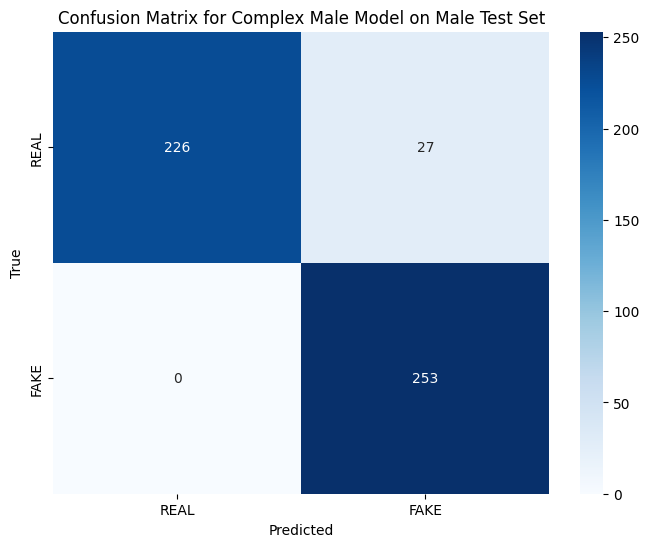

In [ ]:
# Confusion matrix for male test set
cm = confusion_matrix(y_test_male, predicted_labels)

## format the confusion matrix and plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['REAL', 'FAKE'], yticklabels=['REAL', 'FAKE'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Complex Male Model on Male Test Set')
plt.show()

Accuracy: 0.5434


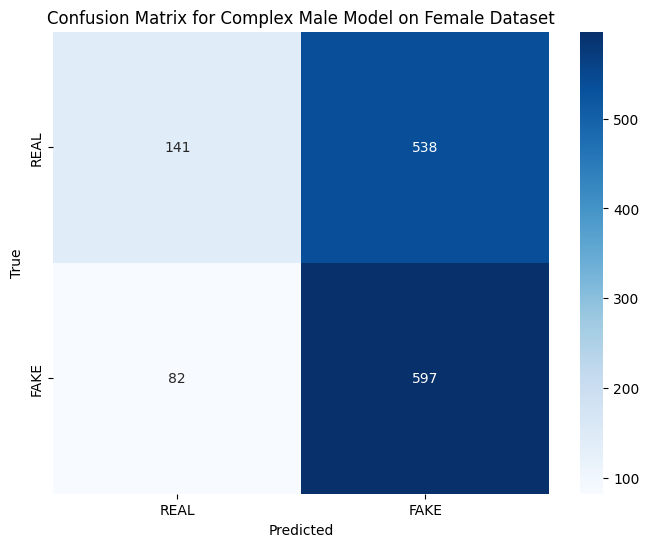

In [ ]:
"""
Complex male model on the female dataset confusion matrix
"""

# Load the dataset
df = pd.read_csv("/content/drive/My Drive/LING_199/combined_female_df.csv")

# rename 'label' to 'LABEL' if necessary
if 'label' in df.columns and 'LABEL' not in df.columns:
    df = df.rename(columns={'label': 'LABEL'})

# undersample the fake class to be the same as the real class
fake_samples = df[df['LABEL'] == 1]
real_samples = df[df['LABEL'] == 0]
fake_samples_undersampled = fake_samples.sample(n=len(real_samples), random_state=42)
df = pd.concat([real_samples, fake_samples_undersampled])

# Separate features and labels
X = df.drop(columns=['LABEL']).values
y = df['LABEL'].values

# Collect all test data in a single tensor
X_test_tensor = torch.tensor(X, dtype=torch.float32).to(device)

# Get predicted probabilities
with torch.no_grad():
    probs = complex_male_model(X_test_tensor).cpu().numpy().flatten()  # Shape: (N,)
    predicted_labels = (probs > 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y, predicted_labels)

# print accuracy
accuracy = (cm[0][0] + cm[1][1]) / (cm[0][0] + cm[0][1] + cm[1][0] + cm[1][1])
print(f"Accuracy: {accuracy:.4f}")

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['REAL', 'FAKE'], yticklabels=['REAL', 'FAKE'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Complex Male Model on Female Dataset')
plt.show()

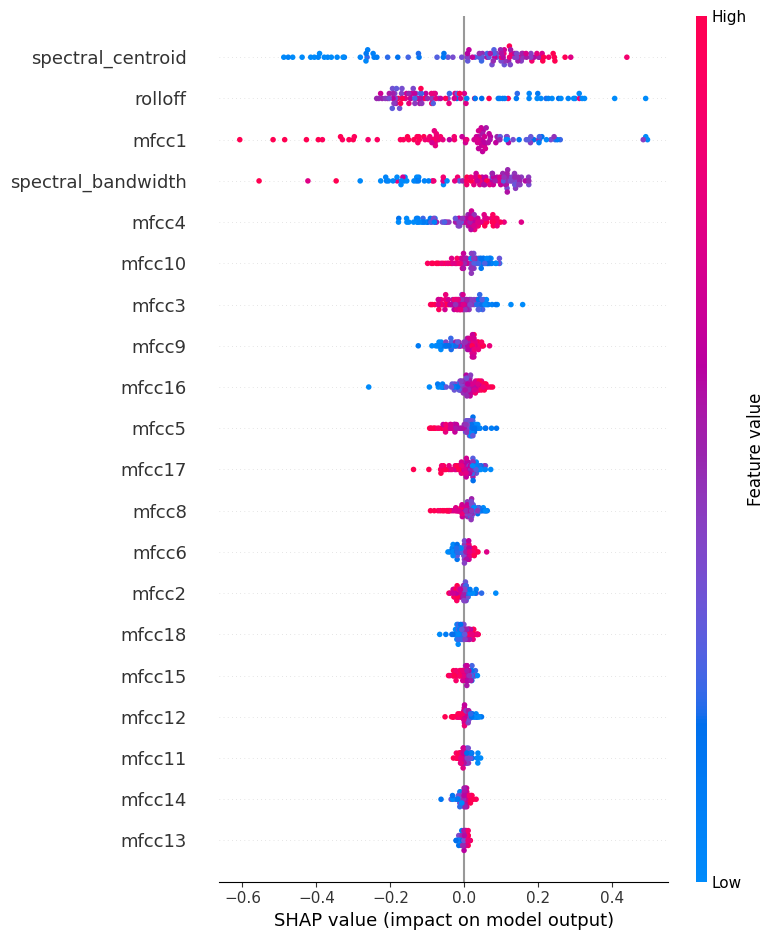

In [ ]:
'''SHAP explainer for complex male model
'''

# Convert model to evaluation mode
complex_male_model.eval()

# prepare data for shap

# get the background
background = torch.tensor(X_train[:100], dtype=torch.float32).to(device)

# subset the first 100 test samples for feature explanation
X_test_tensor = torch.tensor(X_test[:100], dtype=torch.float32).to(device)

# Create a SHAP GradientExplainer
explainer = shap.GradientExplainer(complex_male_model, background)

# Get SHAP values for a subset of the test set
shap_values = explainer.shap_values(X_test_tensor[:100])

# use this for the improved complex NN model
shap_values = shap_values.squeeze(-1)

# extract feature names from original dataframe
feature_names = df.drop(columns=['LABEL']).columns.tolist()

# Convert to numpy if needed
if torch.is_tensor(shap_values):
    shap_values = shap_values.cpu().numpy()

# Create SHAP summary plot
shap.summary_plot(shap_values, X_test[:100], feature_names=feature_names, rng=42)

# Extreme Gradient Boosting

- The XGBoost model is trained using a logistic loss (binary:logistic objective) with a learning rate (eta) of 0.1, a maximum tree depth of 6, and both row (subsample) and column (colsample_bytree) sampling rates set to 0.8 to reduce overfitting. Training runs for up to 100 boosting rounds, but early stopping halts training if no improvement is seen in the evaluation set within 10 rounds. This setup leverages the speed and regularization capabilities of XGBoost, making it well-suited for tabular binary classification tasks with potential nonlinear feature interactions.

- The SHAP summary plot provides a detailed view of how each feature contributes to the model’s predictions. It assigns an importance value (SHAP value) to each feature for each prediction, showing both the magnitude and direction of impact. Features at the top of the SHAP plot are the most influential. Each point represents a SHAP value for an instance, with colors showing the original feature value (red = high, blue = low). For instance, if a feature has high SHAP values when its values are high (red), that means it strongly pushes predictions toward the positive class (FAKE label). This makes SHAP not just a measure of importance, but a visual tool to understand feature behavior and interactions. The XGBoost plot_importance() function ranks features based on how often and how usefully they were split on during training. It offers different importance types (e.g., weight, gain, cover), with the default being weight — the number of times a feature is used in splits across all trees. While this method provides a quick view of what features the model relies on structurally, it does not indicate the direction of influence or how those features interact. Together, these plots help validate the reliability of the model and offer insight into which acoustic features are driving predictions, and in what way — crucial for interpreting how the model distinguishes real from fake male voice samples.

In [ ]:
# load balanced dataset
df = pd.read_csv("/content/drive/My Drive/LING_199/combined_male_df.csv")

# rename 'label' to 'LABEL' if needed
if 'label' in df.columns and 'LABEL' not in df.columns:
    df.rename(columns={'label': 'LABEL'}, inplace=True)

# convert all 'REAL' to 0 and 'FAKE' to 1 in the 'LABEL' column if REAL and FAKE are in the 'LABEL' column
if 'REAL' in df['LABEL'].values and 'FAKE' in df['LABEL'].values:
    df['LABEL'] = df['LABEL'].replace({'REAL': 0, 'FAKE': 1})

# 1. Prepare the data
X = df.drop('LABEL', axis=1)  # Features (all columns except 'LABEL')
y = df['LABEL']               # Target variable

# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% for testing
    random_state=42,
    stratify=y        # Maintain class distribution
)

# Create DMatrix for XGBoost (optimized data structure)
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

In [ ]:
'''Classification report on XGB male model's own test data
'''

# load xgb male model
model = xgb.Booster()
model.load_model('/content/drive/My Drive/LING_199/trained_models/male_models/99.17_xgb_male_model.json')

# Make predictions
y_pred_proba = model.predict(dtest)  # Probabilities
y_pred = (y_pred_proba > 0.5).astype(int)  # Class predictions

# Evaluate the model
print("\nModel Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Model Evaluation:
Accuracy: 0.9917

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       253
           1       0.99      0.99      0.99       348

    accuracy                           0.99       601
   macro avg       0.99      0.99      0.99       601
weighted avg       0.99      0.99      0.99       601



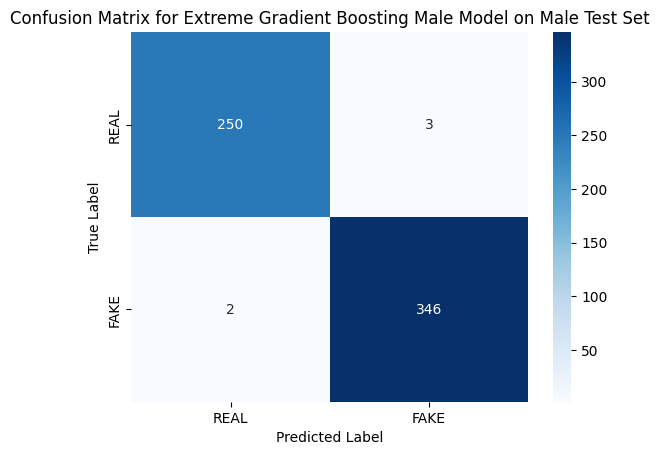

In [ ]:
# Confusion matrix for male test set
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['REAL', 'FAKE'], yticklabels=['REAL', 'FAKE'])
plt.title('Confusion Matrix for Extreme Gradient Boosting Male Model on Male Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

Accuracy: 0.73


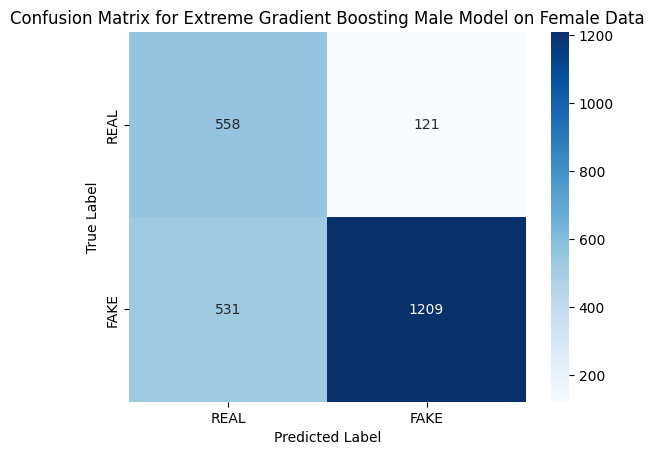

In [ ]:
'''Test the male XGB model on the female dataset
'''

# load the female dataset
female_combined_df = pd.read_csv("/content/drive/My Drive/LING_199/combined_female_df.csv")

# rename 'label' to 'LABEL' if needed
if 'label' in female_combined_df.columns and 'LABEL' not in female_combined_df.columns:
    female_combined_df.rename(columns={'label': 'LABEL'}, inplace=True)

# separate label and features
X_test = female_combined_df.drop(columns=['LABEL'])  # replace 'target_column' if needed
y_test = female_combined_df['LABEL']  # if you have true labels for evaluation

# convert to DMatrix
dtest = xgb.DMatrix(X_test)

# Make predictions
predictions = model.predict(dtest)

if 'y_test' in locals():
    from sklearn.metrics import accuracy_score, classification_report

    # For classification (if your model is classifier)
    predicted_classes = [round(value) for value in predictions]  # for binary classification
    accuracy = accuracy_score(y_test, predicted_classes)
    print(f"Accuracy: {accuracy:.2f}")

# create confusion matrix and plot
cm = confusion_matrix(y_test, predicted_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['REAL', 'FAKE'], yticklabels=['REAL', 'FAKE'])
plt.title('Confusion Matrix for Extreme Gradient Boosting Male Model on Female Data')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

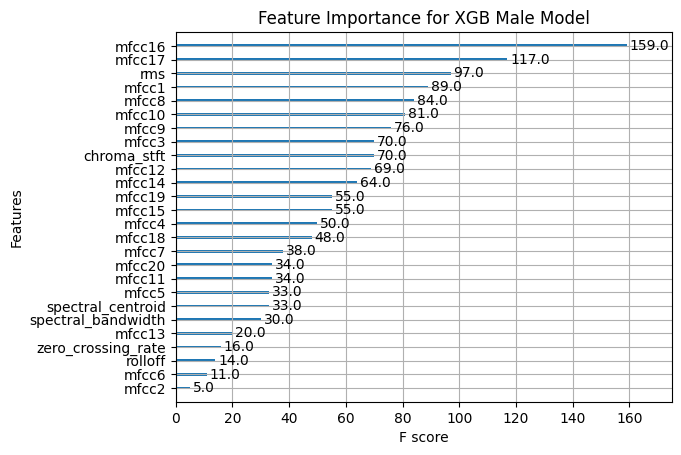

In [ ]:
'''Feature Importance for XGB male model
'''
xgb.plot_importance(model)
plt.title('Feature Importance for XGB Male Model')
plt.show()

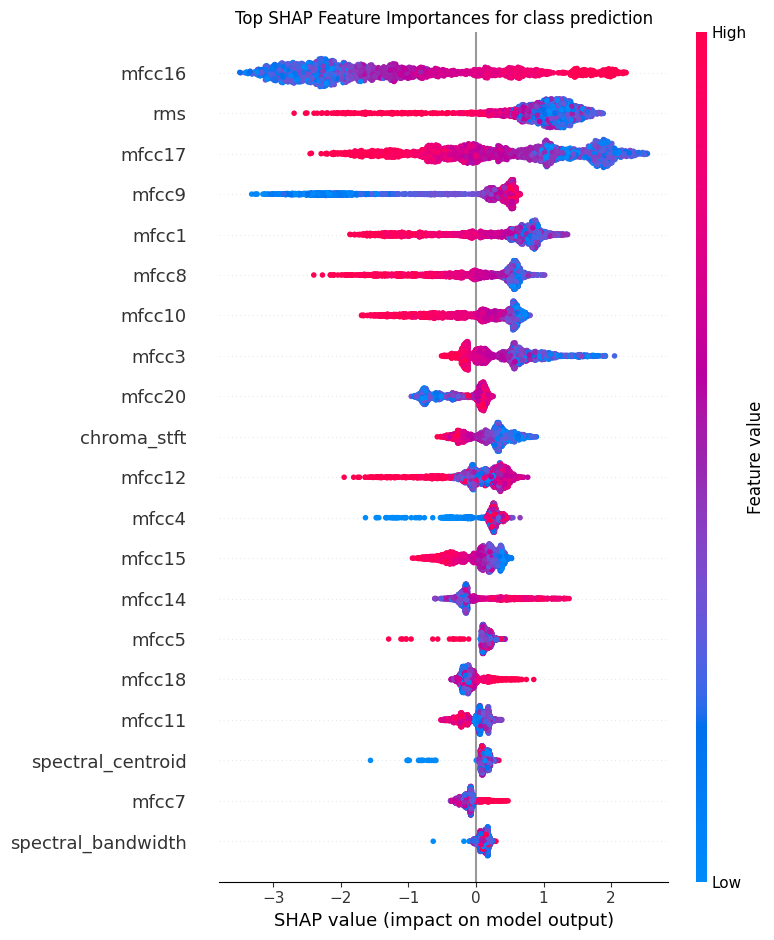

In [ ]:
'''SHAP feature importance for XGB Male Model'''
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(20, 12))
shap.summary_plot(shap_values, X_test, show=False, rng=42)
plt.title('Top SHAP Feature Importances for Male class prediction')
plt.tight_layout()
plt.show()


## Post-hoc EDA

From the models, we see that feature 1, feature 2, feature 3, etc. are important in classifying fake/real audio.

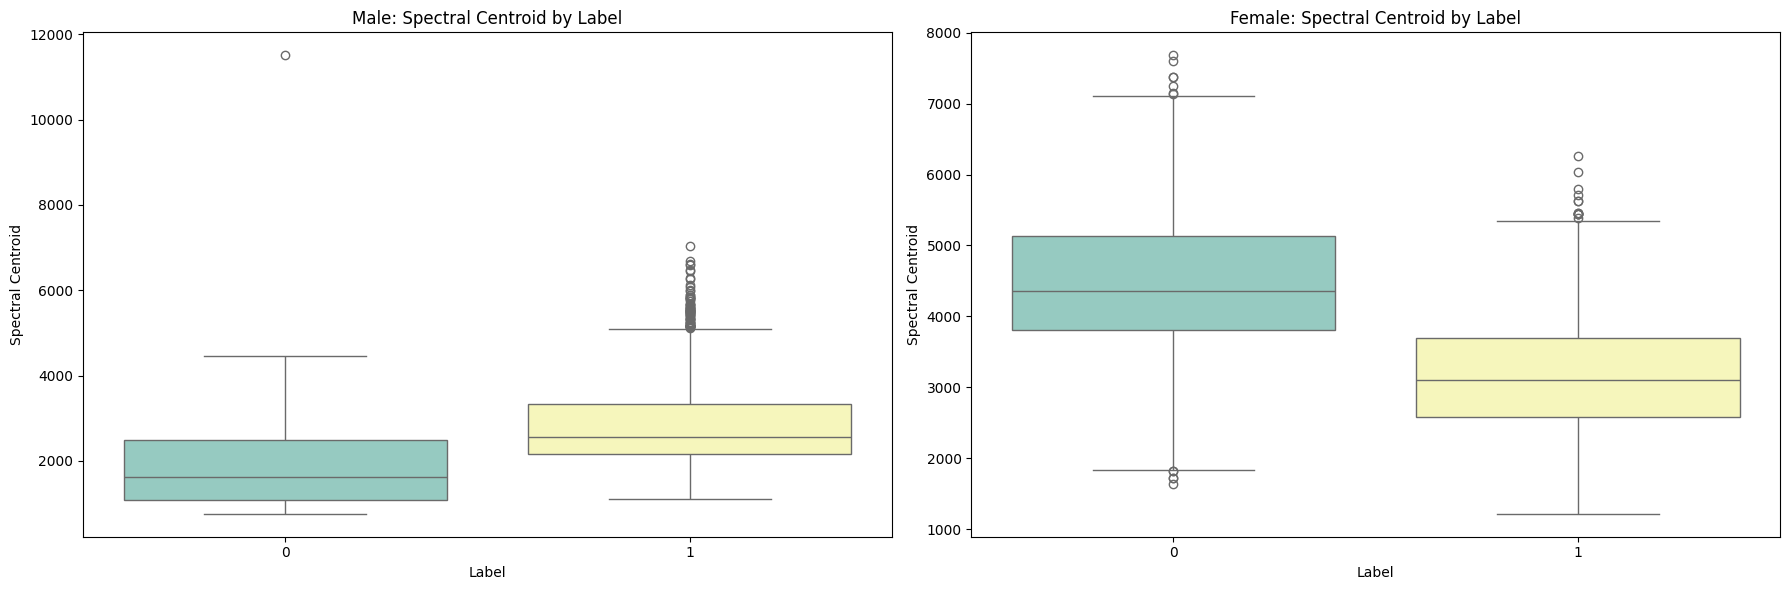

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=False)

# Male dataset plot
sns.boxplot(
    x='LABEL',
    y='spectral_centroid',
    data=df,
    hue='LABEL',
    palette='Set3',
    ax=axes[0],
    legend=False
)
axes[0].set_title('Male Data: Spectral Centroid by Label')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Spectral Centroid')

# Female dataset plot
sns.boxplot(
    x='label',
    y='spectral_centroid',
    data=combined_female_df,
    hue='label',
    palette='Set3',
    ax=axes[1],
    legend=False
)
axes[1].set_title('Female Data: Spectral Centroid by Label')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Spectral Centroid')  # Corrected label

# Display plots
plt.tight_layout()
plt.show()
